In [228]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import maptools
import os

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from multiprocessing import Pool
from skimage.transform import iradon

maptools.job.info()
maptools.plot.dark()
!which python

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
hostname: offline-cn10
SLURM_JOB_ID: 464501
SLURM_JOB_NODELIST: offline-cn10
NPROCS: 48
Memory available: 102.872252416 GB
~/.conda/envs/grainmapper/bin/python


In [167]:
h5path = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/medium_pks.h5' )
parpath = os.path.join( maptools.paths.PROCESS, 'al1050_15pct_center_slice/al1050.par' )
colf = maptools.io.read_peaks(h5path, parpath)

In [168]:
dty_centers = np.unique(colf.dty.round(3))
dty_step = dty_centers[1] - dty_centers[0]
dty_bins = dty_centers - dty_step/2.
dty_bins = np.concatenate([dty_bins, [dty_bins[-1] + dty_step]])

ome_centers = np.unique(colf.omega.round(3))
ome_step = ome_centers[1] - ome_centers[0]
ome_bins = ome_centers - ome_step/2.
ome_bins = np.concatenate([ome_bins, [ome_bins[-1] + ome_step]])

In [169]:
h, _, _ = np.histogram2d(colf.omega, colf.dty, bins=(ome_bins, dty_bins), weights=colf.Number_of_pixels )
sino = h.copy()
sino = sino.T
sino /= np.max(sino, axis=0)

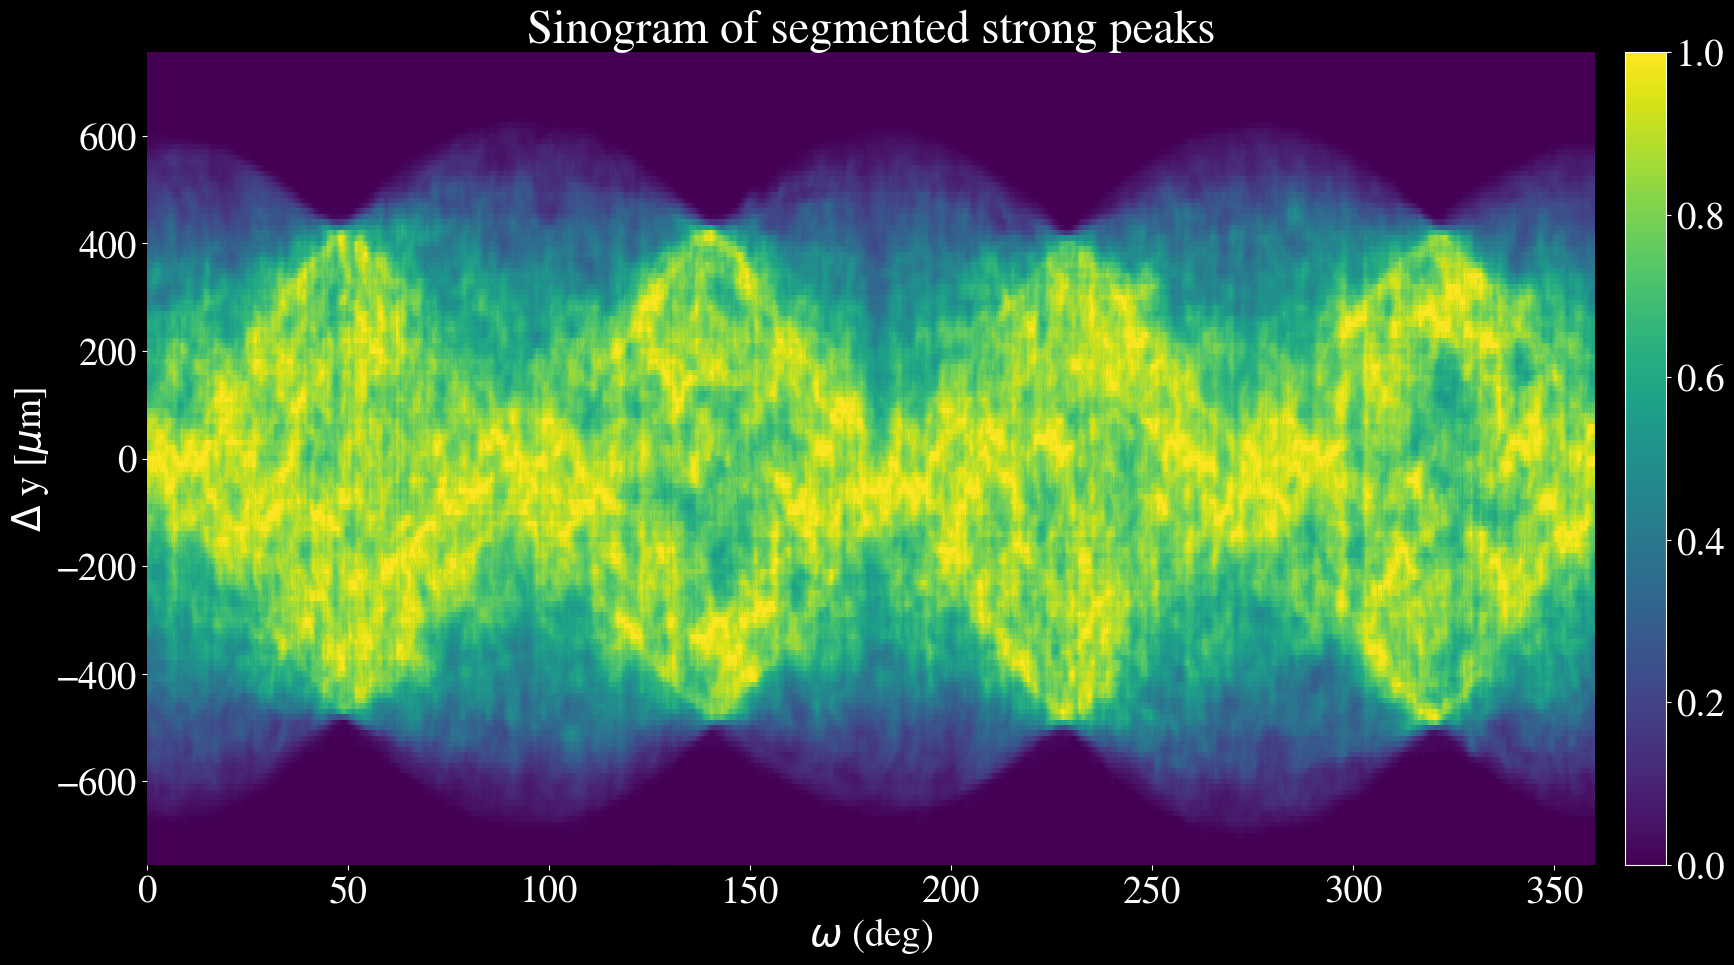

In [170]:
X, Y = np.meshgrid(ome_centers, dty_centers)
plt.style.use('dark_background')
fig, ax = plt.subplots(1, 1, figsize=(18, 10))
im = ax.pcolormesh(X, Y*1000, sino, cmap='viridis', shading='nearest')
ax.set_xlabel(r'$\omega$ (deg)')
ax.set_ylabel(r'$\Delta$ y [$\mu$m]')
fig.colorbar(im, ax=ax, fraction=0.028, pad=0.02)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
ax.set_title('Sinogram of segmented strong peaks')
plt.show()

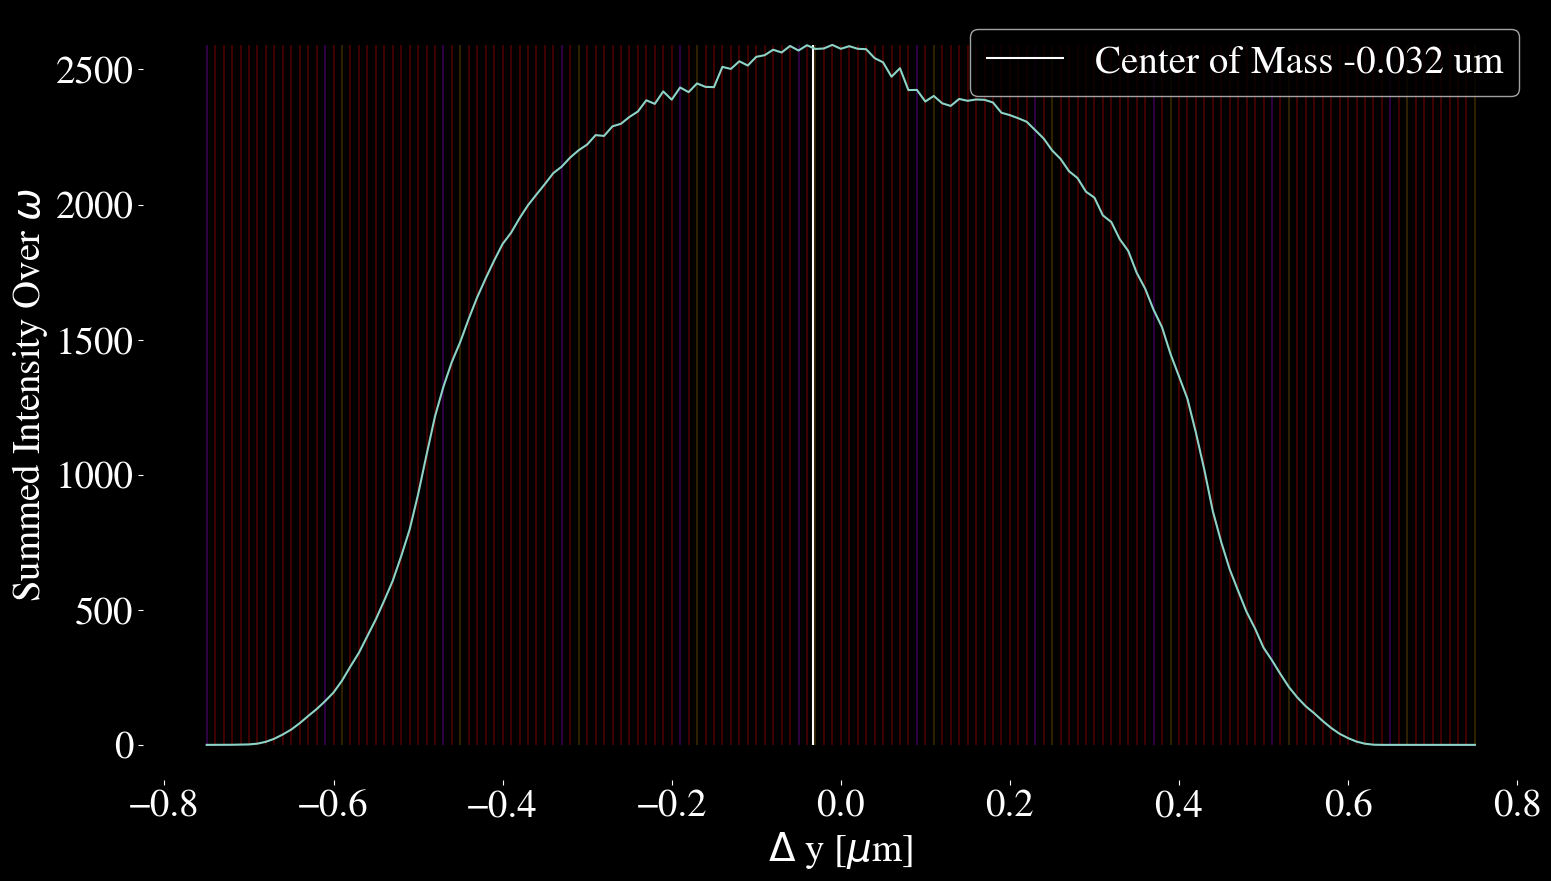

In [179]:
profile = np.sum(sino, axis=1)

rotation_axis_com = np.sum(profile * dty_centers) / np.sum(profile)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

for dty in dty_centers:
    ax.vlines(dty, 0, np.max(profile), color='r', linestyle='-', alpha=0.25)

ax.vlines(rotation_axis_com, 0, np.max(profile), color='w', linestyle='-', label=f'Center of Mass {rotation_axis_com:.3f} um')
ax.legend()
for k in maptools.constants.SCANRANGES:
    ax.vlines(maptools.constants.SCANRANGES[k][0], 0, np.max(profile), color='b', linestyle='-', alpha=0.25)
    ax.vlines(maptools.constants.SCANRANGES[k][1], 0, np.max(profile), color='g', linestyle='-', alpha=0.25)
ax.set_xlabel(r'$\Delta$ y [$\mu$m]')
ax.set_ylabel('Summed Intensity Over $\omega$')
for spine in ax.spines.values():
    spine.set_visible(False)
plt.plot(dty_centers, profile)
plt.show()

In [213]:
import scipy.ndimage

def rec(args):
    ss, angles, shift = args
    ss = scipy.ndimage.shift(ss, (shift, 0))
    return iradon(ss, theta=angles), shift

uni_omega = np.unique(ome_centers)
yshifts = -np.linspace(rotation_axis_com - 2*maptools.constants.DTYSTEP, rotation_axis_com + 2*maptools.constants.DTYSTEP, 11)
pixshifts = yshifts / maptools.constants.DTYSTEP
idxs = [(sino.copy() , uni_omega.copy(), shift) for shift in pixshifts]

with Pool() as p:
    recs = list(tqdm(p.imap(rec, idxs), total=len(idxs)))

  0%|          | 0/11 [00:00<?, ?it/s]

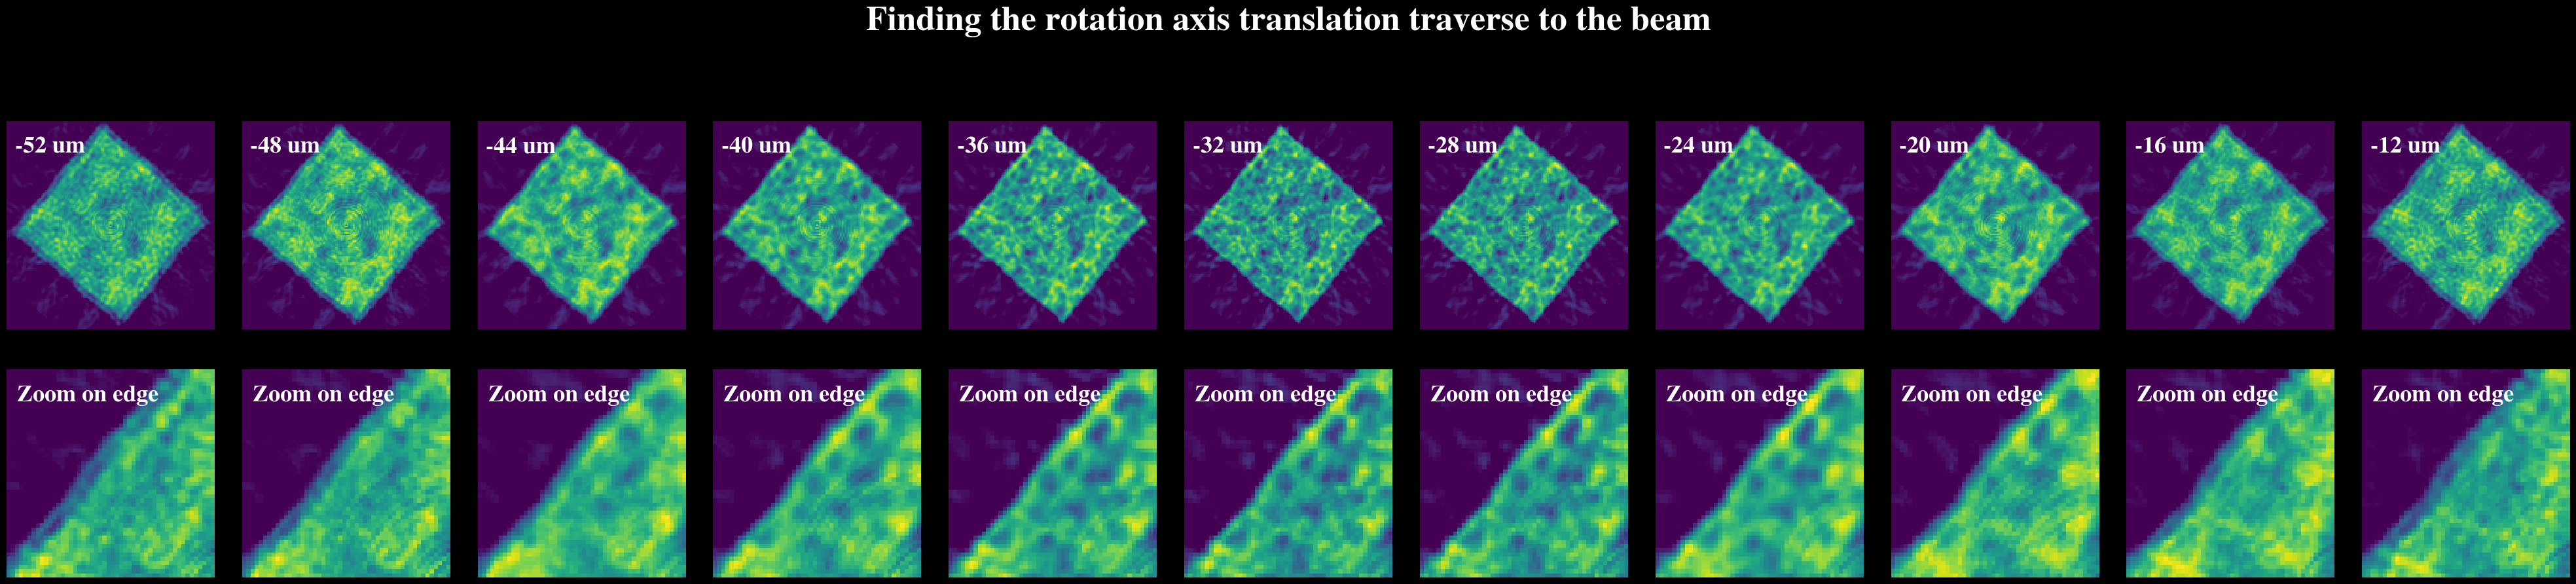

In [ ]:
fig, ax = plt.subplots(2, len(recs), figsize=(40, 10))
for i in range(len(recs)):
    rr, ii = recs[i]
    ax[0,i].imshow(rr.clip(np.max(rr)*0.025)[6:-6, 6:-6], interpolation='nearest')
    ax[0,i].text(5, 20, s + str(abs(np.round(ii*dty_step*1000,0).astype(int)))+' um', fontsize=26, fontweight='bold')
    ax[1,i].text(2, 7, 'Zoom on edge', fontsize=26, fontweight='bold')
    ax[1,i].imshow(rr.clip(np.max(rr)*0.025)[20:70, 20:70], interpolation='nearest')
for a in ax.flatten():
    a.axis('off')
    for spine in a.spines.values():
        spine.set_visible(False)
fig.suptitle('Finding the rotation axis translation traverse to the beam', fontsize=38, fontweight='bold')
plt.tight_layout()
fig.savefig('finding_rotation_axis.png', dpi=400)
plt.show()

In [ ]:
path = os.path.join(maptools.paths.PROCESS, 'al1050_15pct_center_slice/rotation_axis_com.npy')
np.save(path, rotation_axis_com)